# COM763 Portfolio Task 1 — End-to-End Machine Learning Pipeline
## Real-world problem: predicting telecommunications customer churn

**Notebook purpose:** build, compare, debug, evaluate, and export a reproducible binary-classification system that estimates whether a customer is likely to discontinue service.

**Technical scope:** data audit → cleaning → exploratory analysis → leakage-safe preprocessing → baseline and candidate models → cross-validation → hyperparameter tuning → threshold optimisation → test evaluation → error analysis → model export for Streamlit.



# 1. Problem Definition and System Framing

### Machine-learning formulation
- **Task type:** supervised binary classification.
- **Target:** `Churn` (`1 = Yes`, `0 = No`).
- **Prediction unit:** one telecommunications customer account.
- **Intended operational use:** prioritise customers for a human-reviewed retention campaign.
- **Primary ranking metric:** PR-AUC, because the positive class is less common and retention teams care about finding likely churners.
- **Supporting metrics:** ROC-AUC, recall, precision, F1, balanced accuracy, and confusion matrix.
- **Model-selection principle:** choose the strongest cross-validated model, then tune its decision threshold without using the held-out test set.

### Guardrails
This is a teaching demonstration, not an automated decision system. Predictions should not be used to deny service, alter pricing unfairly, or make decisions without human review.

# 2. Reproducibility and Environment Setup

In [1]:
# Core imports and reproducibility controls
from pathlib import Path
import json
import platform
import sys
import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn
from scipy.stats import loguniform

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.exceptions import UndefinedMetricWarning
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    PrecisionRecallDisplay,
    RocCurveDisplay,
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    fbeta_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import (
    GridSearchCV,
    StratifiedKFold,
    cross_val_predict,
    cross_validate,
    train_test_split,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.svm import SVC

warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UndefinedMetricWarning)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Make the notebook work from either the repository root or a notebooks folder.
PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'data').exists() and (PROJECT_ROOT.parent / 'data').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_PATH = PROJECT_ROOT / 'data' / 'Telco-Customer-Churn.csv'
ARTIFACT_DIR = PROJECT_ROOT / 'artifacts'
FIGURE_DIR = PROJECT_ROOT / 'figures'
ARTIFACT_DIR.mkdir(exist_ok=True)
FIGURE_DIR.mkdir(exist_ok=True)

print('Python:', sys.version.split()[0])
print('pandas:', pd.__version__)
print('NumPy:', np.__version__)
print('scikit-learn:', sklearn.__version__)
print('Platform:', platform.platform())
print('Project root:', PROJECT_ROOT.resolve())

/home/oai/.config/matplotlib is not a writable directory


Matplotlib created a temporary cache directory at /tmp/matplotlib-mzawfdou because there was an issue with the default path (/home/oai/.config/matplotlib); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


Python: 3.13.5
pandas: 2.2.3
NumPy: 2.3.5
scikit-learn: 1.8.0
Platform: Linux-4.4.0-x86_64-with-glibc2.41
Project root: /mnt/data/COM763_Task1_Telco_Churn_Project


# 3. Data Loading and Provenance

In [2]:
# Load the local copy of the IBM Telco Customer Churn dataset.
# Source repository: https://github.com/IBM/telco-customer-churn-on-icp4d
if not DATA_PATH.exists():
    raise FileNotFoundError(
        f'Dataset not found at {DATA_PATH}. Keep the data folder in the repository root.'
    )

raw_df = pd.read_csv(DATA_PATH)
print(f'Loaded {raw_df.shape[0]:,} rows and {raw_df.shape[1]} columns.')
raw_df.head()

Loaded 7,043 rows and 21 columns.


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


# 4. Initial Data Audit

In [3]:
# Inspect schema, duplicate identifiers, missing-looking strings, and target balance.
audit = pd.DataFrame({
    'dtype': raw_df.dtypes.astype(str),
    'missing_values': raw_df.isna().sum(),
    'unique_values': raw_df.nunique(dropna=False),
})
audit

,dtype,missing_values,unique_values
customerID,object,0,7043
gender,object,0,2
SeniorCitizen,int64,0,2
Partner,object,0,2
Dependents,object,0,2
tenure,int64,0,73
PhoneService,object,0,2
MultipleLines,object,0,3
InternetService,object,0,3
OnlineSecurity,object,0,3


In [4]:
# Diagnostic checks that expose common data-quality problems.
blank_total_charges = raw_df['TotalCharges'].astype(str).str.strip().eq('').sum()
duplicate_customer_ids = raw_df['customerID'].duplicated().sum()
exact_duplicate_rows = raw_df.duplicated().sum()

print('Blank TotalCharges strings:', blank_total_charges)
print('Duplicate customer IDs:', duplicate_customer_ids)
print('Exact duplicate rows:', exact_duplicate_rows)
print()
print('Target counts:')
print(raw_df['Churn'].value_counts())
print()
print('Target proportions:')
print(raw_df['Churn'].value_counts(normalize=True).round(4))

Blank TotalCharges strings: 11
Duplicate customer IDs: 0
Exact duplicate rows: 0

Target counts:
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Target proportions:
Churn
No     0.7346
Yes    0.2654
Name: proportion, dtype: float64


# 5. Data Cleaning and Debugging Evidence

In [5]:
# Create a clean modelling table without overwriting the raw data.
df = raw_df.copy()

# DEBUGGING FIX 1:
# TotalCharges is read as text because 11 rows contain blank strings.
# Convert invalid strings to NaN so the numeric imputer can handle them inside the pipeline.
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# DEBUGGING FIX 2:
# customerID is an identifier, not a behavioural feature. Keeping it would create noise
# and could encourage memorisation rather than generalisation.
df = df.drop(columns='customerID')

# Encode the target explicitly.
df['Churn'] = df['Churn'].map({'No': 0, 'Yes': 1})

# Fail early if cleaning produced an unexpected target or invalid schema.
assert set(df['Churn'].dropna().unique()) == {0, 1}
assert df['Churn'].isna().sum() == 0
assert df['tenure'].between(0, 72).all()
assert (df['MonthlyCharges'] >= 0).all()

print('Cleaned shape:', df.shape)
print('Missing TotalCharges after conversion:', df['TotalCharges'].isna().sum())
df.head()

Cleaned shape: (7043, 20)
Missing TotalCharges after conversion: 11


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


# 6. Exploratory Data Analysis

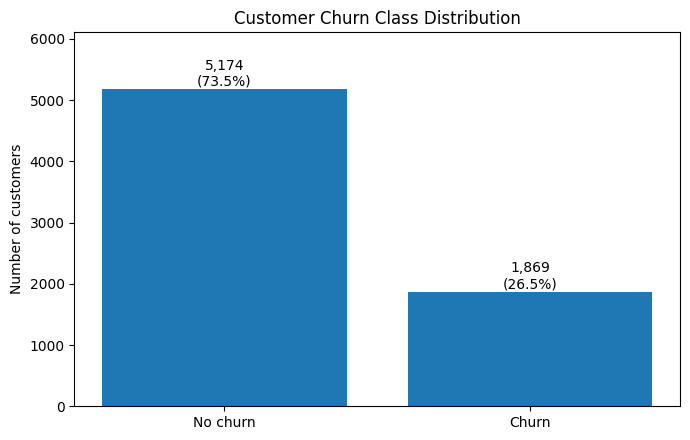

In [6]:
# Target distribution: important for choosing stratified splits and imbalance-aware metrics.
counts = df['Churn'].value_counts().sort_index()
labels = ['No churn', 'Churn']

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.bar(labels, counts.values)
ax.set_title('Customer Churn Class Distribution')
ax.set_ylabel('Number of customers')
for i, value in enumerate(counts.values):
    label_text = f'{value:,}' + chr(10) + f'({value / len(df):.1%})'
    ax.text(i, value + 60, label_text, ha='center')
ax.set_ylim(0, counts.max() * 1.18)
fig.tight_layout()
fig.savefig(FIGURE_DIR / '01_target_distribution.png', dpi=200, bbox_inches='tight')
plt.show()

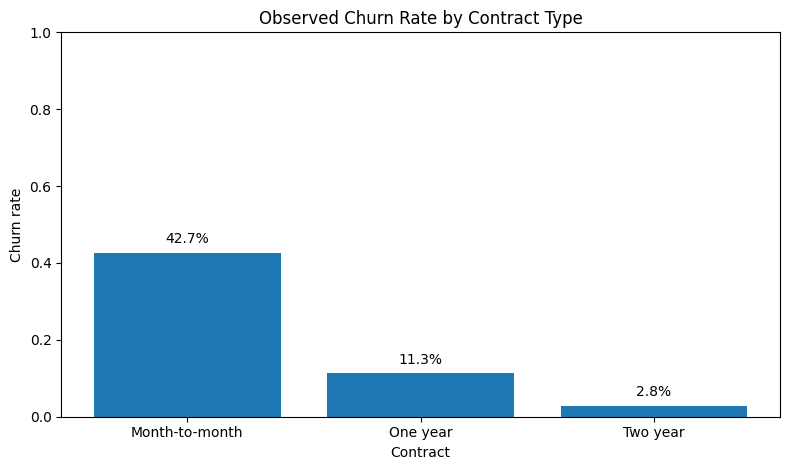

,mean,count
Contract,,
Month-to-month,0.427097,3875
One year,0.112695,1473
Two year,0.028319,1695


In [7]:
# Churn rate by contract type reveals a strong, interpretable relationship.
contract_rates = (
    df.groupby('Contract', observed=True)['Churn']
      .agg(['mean', 'count'])
      .sort_values('mean', ascending=False)
)

fig, ax = plt.subplots(figsize=(8, 4.8))
ax.bar(contract_rates.index, contract_rates['mean'])
ax.set_title('Observed Churn Rate by Contract Type')
ax.set_ylabel('Churn rate')
ax.set_xlabel('Contract')
ax.set_ylim(0, 1)
for i, value in enumerate(contract_rates['mean']):
    ax.text(i, value + 0.025, f'{value:.1%}', ha='center')
fig.tight_layout()
fig.savefig(FIGURE_DIR / '02_churn_by_contract.png', dpi=200, bbox_inches='tight')
plt.show()

contract_rates

In [8]:
# Numeric feature summaries split by the target class.
numeric_summary = (
    df.groupby('Churn')[['tenure', 'MonthlyCharges', 'TotalCharges']]
      .agg(['mean', 'median', 'std'])
      .round(2)
)
numeric_summary

tenure               MonthlyCharges  ...        TotalCharges                  
        mean median    std           mean  ...    std         mean   median      std
Churn                                      ...                                      
0      37.57   38.0  24.11          61.27  ...  31.09      2555.34  1683.60  2329.46
1      17.98   10.0  19.53          74.44  ...  24.67      1531.80   703.55  1890.82

[2 rows x 9 columns]

# 7. Train/Test Split and Leakage Controls

In [9]:
# Separate predictors and target before splitting.
X = df.drop(columns='Churn')
y = df['Churn']

# The test set is held back until all model and threshold choices are complete.
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE,
)

print('Training rows:', len(X_train))
print('Test rows:', len(X_test))
print('Training churn rate:', round(y_train.mean(), 4))
print('Test churn rate:', round(y_test.mean(), 4))

# Leakage checks
assert set(X_train.index).isdisjoint(set(X_test.index))
assert abs(y_train.mean() - y_test.mean()) < 0.01

Training rows: 5634
Test rows: 1409
Training churn rate: 0.2654
Test churn rate: 0.2654


# 8. Feature Handling and Preprocessing Pipeline

In [10]:
# Define columns by semantic role rather than relying on automatic dtype detection.
NUMERIC_FEATURES = ['tenure', 'MonthlyCharges', 'TotalCharges']
CATEGORICAL_FEATURES = [c for c in X.columns if c not in NUMERIC_FEATURES]

numeric_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
])

categorical_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore')),
])

preprocessor = ColumnTransformer(
    transformers=[
        ('numeric', numeric_pipeline, NUMERIC_FEATURES),
        ('categorical', categorical_pipeline, CATEGORICAL_FEATURES),
    ],
    remainder='drop',
    verbose_feature_names_out=False,
)

print('Numeric features:', NUMERIC_FEATURES)
print('Categorical feature count:', len(CATEGORICAL_FEATURES))

Numeric features: ['tenure', 'MonthlyCharges', 'TotalCharges']
Categorical feature count: 16


# 9. Baseline and Candidate Model Implementation

In [11]:
# Candidate models provide different bias/variance and interpretability profiles.
models = {
    'Dummy baseline': DummyClassifier(strategy='prior'),
    'Logistic regression': LogisticRegression(
        max_iter=3000,
        class_weight='balanced',
        solver='liblinear',
        random_state=RANDOM_STATE,
    ),
    'Random forest': RandomForestClassifier(
        n_estimators=300,
        min_samples_leaf=2,
        class_weight='balanced',
        n_jobs=1,
        random_state=RANDOM_STATE,
    ),
    'RBF support vector machine': SVC(
        C=1.0,
        kernel='rbf',
        class_weight='balanced',
        probability=True,
        random_state=RANDOM_STATE,
    ),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring = {
    'roc_auc': 'roc_auc',
    'pr_auc': 'average_precision',
    'balanced_accuracy': 'balanced_accuracy',
    'f1': 'f1',
    'recall': 'recall',
    'precision': 'precision',
}

candidate_pipelines = {
    name: Pipeline([('preprocessor', clone(preprocessor)), ('model', model)])
    for name, model in models.items()
}

# 10. Cross-Validated Experimental Comparison

In [12]:
# Evaluate every model on exactly the same stratified folds.
cv_rows = []
for model_name, pipeline in candidate_pipelines.items():
    scores = cross_validate(
        pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=1,
        return_train_score=False,
    )
    row = {'model': model_name}
    for metric_name in scoring:
        values = scores[f'test_{metric_name}']
        row[f'{metric_name}_mean'] = values.mean()
        row[f'{metric_name}_std'] = values.std(ddof=1)
    cv_rows.append(row)

cv_results = pd.DataFrame(cv_rows).sort_values('pr_auc_mean', ascending=False).reset_index(drop=True)
cv_results.to_csv(ARTIFACT_DIR / 'cv_model_comparison.csv', index=False)
cv_results.round(4)

,model,roc_auc_mean,roc_auc_std,pr_auc_mean,pr_auc_std,balanced_accuracy_mean,balanced_accuracy_std,f1_mean,f1_std,recall_mean,recall_std,precision_mean,precision_std
0,Logistic regression,0.8459,0.0139,0.6600,0.0219,0.7656,0.0230,0.6286,0.0258,0.8013,0.0424,0.5174,0.0209
1,Random forest,0.8371,0.0115,0.6383,0.0337,0.7432,0.0185,0.6189,0.0262,0.6448,0.0319,0.5955,0.0287
2,RBF support vector machine,0.8267,0.0108,0.6068,0.0285,0.7599,0.0199,0.6236,0.0219,0.7799,0.0417,0.5197,0.0146
3,Dummy baseline,0.5000,0.0000,0.2654,0.0001,0.5000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000


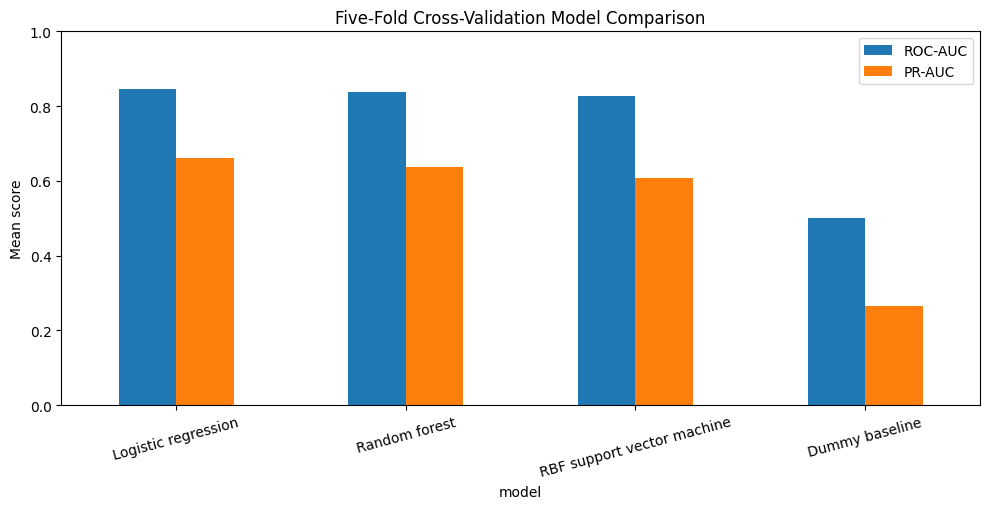

In [13]:
# Visual comparison of the two ranking metrics.
plot_df = cv_results.set_index('model')[['roc_auc_mean', 'pr_auc_mean']]
ax = plot_df.plot(kind='bar', figsize=(10, 5.2), rot=15)
ax.set_title('Five-Fold Cross-Validation Model Comparison')
ax.set_ylabel('Mean score')
ax.set_ylim(0, 1)
ax.legend(['ROC-AUC', 'PR-AUC'])
fig = ax.get_figure()
fig.tight_layout()
fig.savefig(FIGURE_DIR / '03_cv_model_comparison.png', dpi=200, bbox_inches='tight')
plt.show()

# 11. Evidence-Based Model Selection and Hyperparameter Tuning

In [14]:
# Select the strongest non-dummy candidate by mean PR-AUC.
selected_model_name = (
    cv_results.loc[cv_results['model'] != 'Dummy baseline']
              .sort_values('pr_auc_mean', ascending=False)
              .iloc[0]['model']
)
print('Cross-validation winner:', selected_model_name)

# Tune the regularisation strength of the interpretable deployment candidate.
# Grid search is deterministic and uses only the training set.
if selected_model_name != 'Logistic regression':
    print('Note: model ranking changed. Logistic regression is retained as the interpretable deployment candidate.')

logistic_pipeline = candidate_pipelines['Logistic regression']
parameter_grid = {
    'model__C': [0.01, 0.03, 0.1, 0.3, 1.0, 3.0, 10.0],
}

search = GridSearchCV(
    estimator=logistic_pipeline,
    param_grid=parameter_grid,
    scoring='average_precision',
    cv=cv,
    n_jobs=1,
    return_train_score=True,
    refit=True,
)
search.fit(X_train, y_train)

print('Best cross-validated PR-AUC:', round(search.best_score_, 4))
print('Best parameters:', search.best_params_)

search_results = pd.DataFrame(search.cv_results_).sort_values('rank_test_score')
search_results[
    ['rank_test_score', 'mean_test_score', 'std_test_score', 'mean_train_score', 'param_model__C']
].head(10).round(4)

Cross-validation winner: Logistic regression


Best cross-validated PR-AUC: 0.66
Best parameters: {'model__C': 1.0}


,rank_test_score,mean_test_score,std_test_score,mean_train_score,param_model__C
4,1,0.6600,0.0196,0.6648,1.00
3,2,0.6600,0.0193,0.6644,0.30
5,3,0.6595,0.0192,0.6646,3.00
2,4,0.6592,0.0192,0.6636,0.10
1,5,0.6591,0.0182,0.6623,0.03
6,6,0.6589,0.0190,0.6642,10.00
0,7,0.6583,0.0174,0.6608,0.01


# 12. Decision-Threshold Optimisation Without Test Leakage

In [15]:
# Use out-of-fold probabilities from the training set to choose an operating threshold.
# F2 weights recall more heavily than precision, matching a retention-screening scenario.
best_estimator_template = search.best_estimator_
oof_probabilities = cross_val_predict(
    best_estimator_template,
    X_train,
    y_train,
    cv=cv,
    method='predict_proba',
    n_jobs=1,
)[:, 1]

precision_values, recall_values, thresholds = precision_recall_curve(y_train, oof_probabilities)

# precision_recall_curve returns one extra precision/recall point with no matching threshold.
precision_for_thresholds = precision_values[:-1]
recall_for_thresholds = recall_values[:-1]
denominator = (4 * precision_for_thresholds) + recall_for_thresholds
f2_values = np.divide(
    5 * precision_for_thresholds * recall_for_thresholds,
    denominator,
    out=np.zeros_like(denominator),
    where=denominator != 0,
)

best_threshold_index = int(np.argmax(f2_values))
best_threshold = float(thresholds[best_threshold_index])

print('Default threshold: 0.500')
print('Training-only F2-optimal threshold:', round(best_threshold, 4))
print('Out-of-fold F2 at chosen threshold:', round(float(f2_values[best_threshold_index]), 4))

Default threshold: 0.500
Training-only F2-optimal threshold: 0.3223
Out-of-fold F2 at chosen threshold: 0.7525


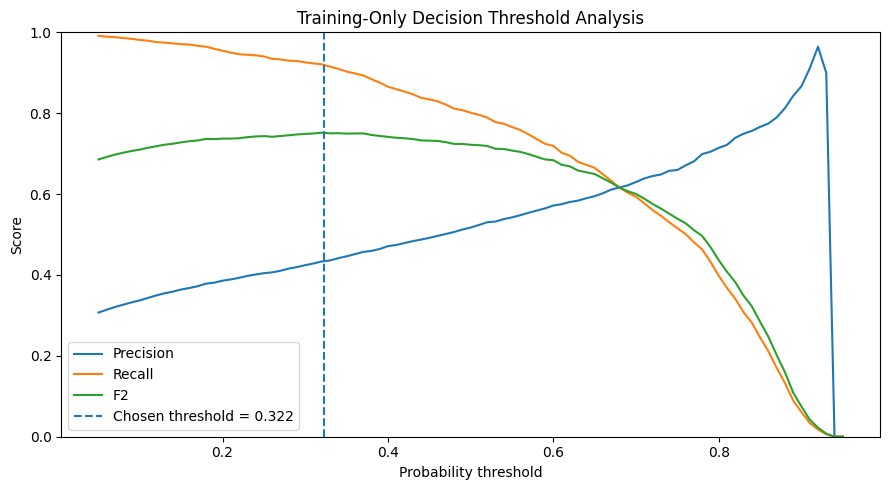

In [16]:
# Visualise the threshold trade-off used to select the deployment operating point.
threshold_metrics = []
for threshold in np.linspace(0.05, 0.95, 91):
    pred = (oof_probabilities >= threshold).astype(int)
    threshold_metrics.append({
        'threshold': threshold,
        'precision': precision_score(y_train, pred, zero_division=0),
        'recall': recall_score(y_train, pred, zero_division=0),
        'f2': fbeta_score(y_train, pred, beta=2, zero_division=0),
    })
threshold_df = pd.DataFrame(threshold_metrics)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(threshold_df['threshold'], threshold_df['precision'], label='Precision')
ax.plot(threshold_df['threshold'], threshold_df['recall'], label='Recall')
ax.plot(threshold_df['threshold'], threshold_df['f2'], label='F2')
ax.axvline(best_threshold, linestyle='--', label=f'Chosen threshold = {best_threshold:.3f}')
ax.set_title('Training-Only Decision Threshold Analysis')
ax.set_xlabel('Probability threshold')
ax.set_ylabel('Score')
ax.set_ylim(0, 1)
ax.legend()
fig.tight_layout()
fig.savefig(FIGURE_DIR / '04_threshold_analysis.png', dpi=200, bbox_inches='tight')
plt.show()

# 13. Final Fit and Held-Out Test Evaluation

In [17]:
# Fit once on the complete training set after every modelling decision is fixed.
final_pipeline = clone(search.best_estimator_)
final_pipeline.fit(X_train, y_train)

test_probabilities = final_pipeline.predict_proba(X_test)[:, 1]
test_predictions_default = (test_probabilities >= 0.50).astype(int)
test_predictions_tuned = (test_probabilities >= best_threshold).astype(int)

def metric_row(name, y_true, y_pred, y_prob):
    return {
        'operating_point': name,
        'accuracy': accuracy_score(y_true, y_pred),
        'balanced_accuracy': balanced_accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred, zero_division=0),
        'recall': recall_score(y_true, y_pred, zero_division=0),
        'f1': f1_score(y_true, y_pred, zero_division=0),
        'f2': fbeta_score(y_true, y_pred, beta=2, zero_division=0),
        'roc_auc': roc_auc_score(y_true, y_prob),
        'pr_auc': average_precision_score(y_true, y_prob),
    }

test_metrics = pd.DataFrame([
    metric_row('Default threshold (0.50)', y_test, test_predictions_default, test_probabilities),
    metric_row(f'Tuned threshold ({best_threshold:.3f})', y_test, test_predictions_tuned, test_probabilities),
])

test_metrics.to_csv(ARTIFACT_DIR / 'test_metrics.csv', index=False)
test_metrics.round(4)

,operating_point,accuracy,balanced_accuracy,precision,recall,f1,f2,roc_auc,pr_auc
0,Default threshold (0.50),0.7381,0.7526,0.5043,0.7834,0.6136,0.7053,0.8415,0.6325
1,Tuned threshold (0.322),0.6657,0.7468,0.4382,0.9198,0.5936,0.7541,0.8415,0.6325


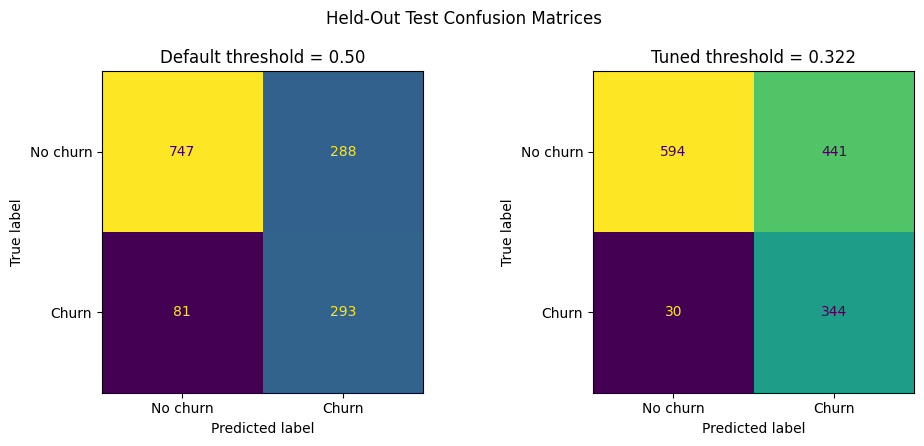

In [18]:
# Confusion matrices show the practical change in false negatives and false positives.
fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    test_predictions_default,
    display_labels=['No churn', 'Churn'],
    values_format='d',
    ax=axes[0],
    colorbar=False,
)
axes[0].set_title('Default threshold = 0.50')

ConfusionMatrixDisplay.from_predictions(
    y_test,
    test_predictions_tuned,
    display_labels=['No churn', 'Churn'],
    values_format='d',
    ax=axes[1],
    colorbar=False,
)
axes[1].set_title(f'Tuned threshold = {best_threshold:.3f}')

fig.suptitle('Held-Out Test Confusion Matrices')
fig.tight_layout()
fig.savefig(FIGURE_DIR / '05_confusion_matrices.png', dpi=200, bbox_inches='tight')
plt.show()

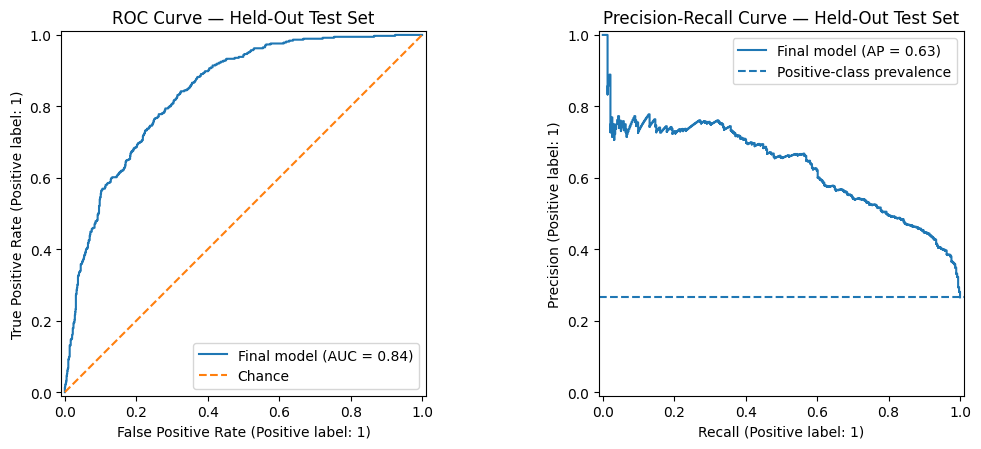

In [19]:
# ROC and precision-recall curves use probability rankings and do not depend on one threshold.
fig, axes = plt.subplots(1, 2, figsize=(11, 4.6))
RocCurveDisplay.from_predictions(y_test, test_probabilities, ax=axes[0], name='Final model')
axes[0].plot([0, 1], [0, 1], linestyle='--', label='Chance')
axes[0].set_title('ROC Curve — Held-Out Test Set')
axes[0].legend()

PrecisionRecallDisplay.from_predictions(y_test, test_probabilities, ax=axes[1], name='Final model')
axes[1].axhline(y_test.mean(), linestyle='--', label='Positive-class prevalence')
axes[1].set_title('Precision-Recall Curve — Held-Out Test Set')
axes[1].legend()

fig.tight_layout()
fig.savefig(FIGURE_DIR / '06_roc_pr_curves.png', dpi=200, bbox_inches='tight')
plt.show()

In [20]:
# Detailed classification report at the tuned operating threshold.
report = classification_report(
    y_test,
    test_predictions_tuned,
    target_names=['No churn', 'Churn'],
    output_dict=True,
    zero_division=0,
)
pd.DataFrame(report).T.round(4)

,precision,recall,f1-score,support
No churn,0.9519,0.5739,0.7161,1035.0000
Churn,0.4382,0.9198,0.5936,374.0000
accuracy,0.6657,0.6657,0.6657,0.6657
macro avg,0.6951,0.7468,0.6549,1409.0000
weighted avg,0.8156,0.6657,0.6836,1409.0000


# 14. Bootstrap Confidence Intervals for Test Metrics

In [21]:
# Bootstrap the held-out test set to quantify sampling uncertainty.
# All metrics are calculated in one loop to keep the notebook efficient.
rng = np.random.default_rng(RANDOM_STATE)
bootstrap_records = []
y_test_array = y_test.to_numpy()

for _ in range(300):
    idx = rng.integers(0, len(y_test_array), len(y_test_array))
    y_sample = y_test_array[idx]
    probability_sample = test_probabilities[idx]
    if len(np.unique(y_sample)) < 2:
        continue
    prediction_sample = (probability_sample >= best_threshold).astype(int)
    bootstrap_records.append({
        'ROC-AUC': roc_auc_score(y_sample, probability_sample),
        'PR-AUC': average_precision_score(y_sample, probability_sample),
        'Recall': recall_score(y_sample, prediction_sample, zero_division=0),
        'Precision': precision_score(y_sample, prediction_sample, zero_division=0),
        'F2': fbeta_score(y_sample, prediction_sample, beta=2, zero_division=0),
    })

bootstrap_samples = pd.DataFrame(bootstrap_records)
bootstrap_ci = (
    bootstrap_samples.quantile([0.025, 0.5, 0.975])
                     .T
                     .reset_index()
                     .rename(columns={'index': 'metric', 0.025: '2.5%', 0.5: 'median', 0.975: '97.5%'})
)
bootstrap_ci.to_csv(ARTIFACT_DIR / 'bootstrap_confidence_intervals.csv', index=False)
bootstrap_ci.round(4)

,metric,2.5%,median,97.5%
0,ROC-AUC,0.8188,0.8420,0.8646
1,PR-AUC,0.5803,0.6336,0.6820
2,Recall,0.8896,0.9210,0.9501
3,Precision,0.3991,0.4366,0.4733
4,F2,0.7194,0.7550,0.7790


# 15. Error Analysis

In [22]:
# Attach predictions to the untouched test records for systematic error inspection.
error_analysis = X_test.copy()
error_analysis['actual_churn'] = y_test
error_analysis['predicted_churn'] = test_predictions_tuned
error_analysis['churn_probability'] = test_probabilities
error_analysis['error_type'] = np.select(
    [
        (error_analysis['actual_churn'] == 1) & (error_analysis['predicted_churn'] == 0),
        (error_analysis['actual_churn'] == 0) & (error_analysis['predicted_churn'] == 1),
        (error_analysis['actual_churn'] == 1) & (error_analysis['predicted_churn'] == 1),
    ],
    ['False negative', 'False positive', 'True positive'],
    default='True negative',
)

error_counts = error_analysis['error_type'].value_counts()
error_counts

error_type
True negative     594
False positive    441
True positive     344
False negative     30
Name: count, dtype: int64

In [23]:
# Compare selected behavioural characteristics across outcome/error groups.
error_group_summary = (
    error_analysis.groupby('error_type')[['tenure', 'MonthlyCharges', 'TotalCharges', 'churn_probability']]
                  .mean()
                  .round(2)
)
error_group_summary

,tenure,MonthlyCharges,TotalCharges,churn_probability
error_type,,,,
False negative,44.33,71.53,3619.89,0.20
False positive,21.88,70.16,1860.50,0.60
True negative,49.09,54.12,2971.67,0.11
True positive,14.03,72.88,1207.18,0.72


In [24]:
# Subgroup checks do not prove fairness, but they can reveal large performance differences.
def subgroup_metrics(frame, group_column):
    rows = []
    for group_value, group_df in frame.groupby(group_column, observed=True):
        rows.append({
            'group_variable': group_column,
            'group': group_value,
            'n': len(group_df),
            'churn_prevalence': group_df['actual_churn'].mean(),
            'recall': recall_score(group_df['actual_churn'], group_df['predicted_churn'], zero_division=0),
            'precision': precision_score(group_df['actual_churn'], group_df['predicted_churn'], zero_division=0),
            'false_positive_rate': (
                ((group_df['actual_churn'] == 0) & (group_df['predicted_churn'] == 1)).sum()
                / max((group_df['actual_churn'] == 0).sum(), 1)
            ),
        })
    return pd.DataFrame(rows)

subgroup_results = pd.concat([
    subgroup_metrics(error_analysis, 'gender'),
    subgroup_metrics(error_analysis, 'SeniorCitizen'),
], ignore_index=True)
subgroup_results.to_csv(ARTIFACT_DIR / 'subgroup_metrics.csv', index=False)
subgroup_results.round(4)

,group_variable,group,n,churn_prevalence,recall,precision,false_positive_rate
0,gender,Female,687,0.2809,0.9119,0.4583,0.4211
1,gender,Male,722,0.2507,0.9282,0.4190,0.4307
2,SeniorCitizen,0,1187,0.2325,0.8986,0.4099,0.3919
3,SeniorCitizen,1,222,0.4414,0.9796,0.5333,0.6774


# 16. Model Interpretation

In [25]:
# Extract standardised logistic-regression coefficients after preprocessing.
feature_names = final_pipeline.named_steps['preprocessor'].get_feature_names_out()
coefficients = final_pipeline.named_steps['model'].coef_[0]

coefficient_table = (
    pd.DataFrame({'feature': feature_names, 'coefficient': coefficients})
      .assign(abs_coefficient=lambda d: d['coefficient'].abs())
      .sort_values('abs_coefficient', ascending=False)
)
coefficient_table.to_csv(ARTIFACT_DIR / 'logistic_coefficients.csv', index=False)
coefficient_table.head(15).round(4)

,feature,coefficient,abs_coefficient
0,tenure,-1.1406,1.1406
39,Contract_Two year,-0.7763,0.7763
17,InternetService_Fiber optic,0.7109,0.7109
1,MonthlyCharges,-0.6764,0.6764
37,Contract_Month-to-month,0.6601,0.6601
16,InternetService_DSL,-0.6226,0.6226
2,TotalCharges,0.4736,0.4736
36,StreamingMovies_Yes,0.2780,0.2780
26,DeviceProtection_No internet service,-0.2750,0.2750
20,OnlineSecurity_No internet service,-0.2750,0.2750


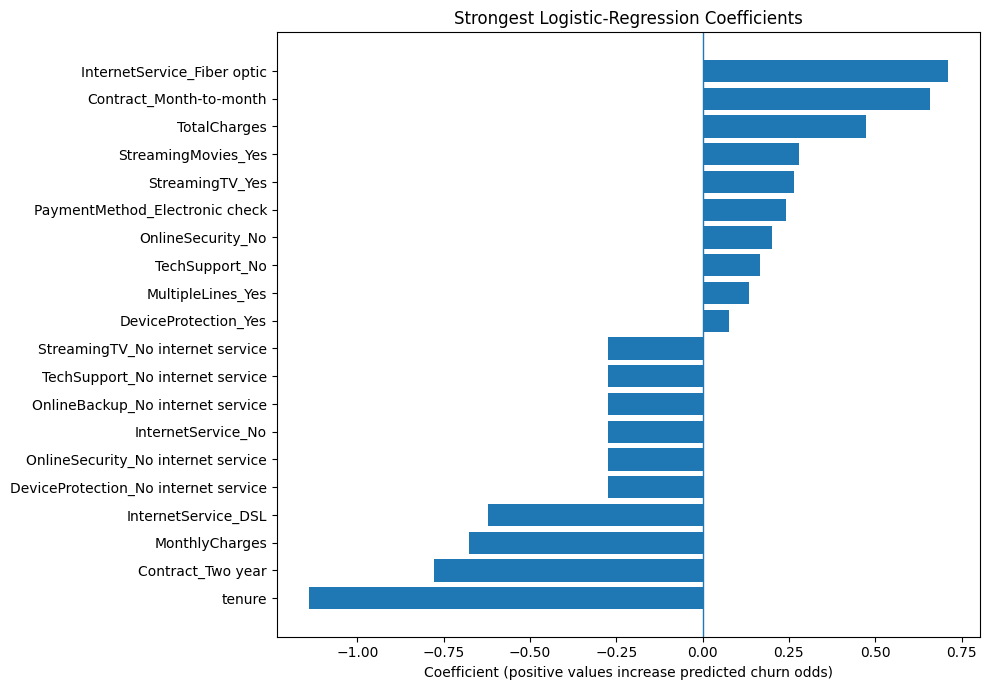

In [26]:
# Plot strongest positive and negative associations.
negative = coefficient_table.nsmallest(10, 'coefficient').sort_values('coefficient')
positive = coefficient_table.nlargest(10, 'coefficient').sort_values('coefficient')
plot_coefficients = pd.concat([negative, positive])

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(plot_coefficients['feature'], plot_coefficients['coefficient'])
ax.axvline(0, linewidth=1)
ax.set_title('Strongest Logistic-Regression Coefficients')
ax.set_xlabel('Coefficient (positive values increase predicted churn odds)')
fig.tight_layout()
fig.savefig(FIGURE_DIR / '07_logistic_coefficients.png', dpi=200, bbox_inches='tight')
plt.show()

In [27]:
# Model-agnostic permutation importance on a reproducible test-set sample.
# Sampling keeps this optional interpretation step fast enough for ordinary laptops.
importance_sample = X_test.sample(n=min(400, len(X_test)), random_state=RANDOM_STATE)
importance_target = y_test.loc[importance_sample.index]

permutation = permutation_importance(
    final_pipeline,
    importance_sample,
    importance_target,
    scoring='average_precision',
    n_repeats=3,
    random_state=RANDOM_STATE,
    n_jobs=1,
)
permutation_table = (
    pd.DataFrame({
        'feature': importance_sample.columns,
        'importance_mean': permutation.importances_mean,
        'importance_std': permutation.importances_std,
    })
    .sort_values('importance_mean', ascending=False)
)
permutation_table.to_csv(ARTIFACT_DIR / 'permutation_importance.csv', index=False)
permutation_table.head(12).round(4)

,feature,importance_mean,importance_std
4,tenure,0.2205,0.0088
7,InternetService,0.1086,0.0468
14,Contract,0.0691,0.0106
17,MonthlyCharges,0.0495,0.0134
12,StreamingTV,0.0347,0.0179
18,TotalCharges,0.0305,0.0172
8,OnlineSecurity,0.0265,0.0058
11,TechSupport,0.0237,0.0051
15,PaperlessBilling,0.0173,0.0112
9,OnlineBackup,0.0150,0.0034


# 17. Robustness and Schema Tests

In [28]:
# Test 1: the pipeline must accept a previously unseen category without failing.
robustness_row = X_test.iloc[[0]].copy()
robustness_row.loc[:, 'PaymentMethod'] = 'New digital wallet category'
robustness_probability = final_pipeline.predict_proba(robustness_row)[:, 1][0]
assert 0 <= robustness_probability <= 1
print('Unseen-category test passed. Probability:', round(float(robustness_probability), 4))

# Test 2: the pipeline must impute a missing numeric value at prediction time.
missing_value_row = X_test.iloc[[1]].copy()
missing_value_row.loc[:, 'TotalCharges'] = np.nan
missing_value_probability = final_pipeline.predict_proba(missing_value_row)[:, 1][0]
assert 0 <= missing_value_probability <= 1
print('Missing-value test passed. Probability:', round(float(missing_value_probability), 4))

# Test 3: expected input schema must match deployment metadata.
assert list(X.columns) == NUMERIC_FEATURES + [c for c in X.columns if c not in NUMERIC_FEATURES] or set(X.columns) == set(NUMERIC_FEATURES + CATEGORICAL_FEATURES)
print('Schema test passed with', X.shape[1], 'features.')

Unseen-category test passed. Probability: 0.1339
Missing-value test passed. Probability: 0.8647
Schema test passed with 19 features.


# 18. Export the Deployable Pipeline and Metadata

In [29]:
# Save the complete preprocessing + classifier object. The Streamlit app does not
# need to reproduce any cleaning or encoding logic separately.
model_path = ARTIFACT_DIR / 'churn_pipeline.joblib'
joblib.dump(final_pipeline, model_path)

sample_input = X_test.iloc[[0]].to_dict(orient='records')[0]
with open(ARTIFACT_DIR / 'sample_input.json', 'w', encoding='utf-8') as file:
    json.dump(sample_input, file, indent=2)

metadata = {
    'project': 'COM763 Portfolio Task 1 — Telco Customer Churn',
    'model_type': type(final_pipeline.named_steps['model']).__name__,
    'target': 'Churn',
    'positive_class': 1,
    'decision_threshold': best_threshold,
    'feature_order': list(X.columns),
    'numeric_features': NUMERIC_FEATURES,
    'categorical_features': CATEGORICAL_FEATURES,
    'training_rows': int(len(X_train)),
    'test_rows': int(len(X_test)),
    'random_state': RANDOM_STATE,
    'best_hyperparameters': search.best_params_,
    'test_metrics_tuned_threshold': {
        key: float(value)
        for key, value in test_metrics.iloc[1].drop('operating_point').items()
    },
    'versions': {
        'python': sys.version.split()[0],
        'pandas': pd.__version__,
        'numpy': np.__version__,
        'scikit_learn': sklearn.__version__,
        'joblib': joblib.__version__,
    },
}

with open(ARTIFACT_DIR / 'model_metadata.json', 'w', encoding='utf-8') as file:
    json.dump(metadata, file, indent=2)

print('Saved model:', model_path)
print('Saved metadata:', ARTIFACT_DIR / 'model_metadata.json')
print('Saved figures:', len(list(FIGURE_DIR.glob('*.png'))))

Saved model: /mnt/data/COM763_Task1_Telco_Churn_Project/artifacts/churn_pipeline.joblib
Saved metadata: /mnt/data/COM763_Task1_Telco_Churn_Project/artifacts/model_metadata.json
Saved figures: 7


# 19. Reload and Deployment Smoke Test

In [30]:
# Reload from disk to verify that deployment will not depend on notebook memory.
reloaded_model = joblib.load(ARTIFACT_DIR / 'churn_pipeline.joblib')
with open(ARTIFACT_DIR / 'model_metadata.json', encoding='utf-8') as file:
    reloaded_metadata = json.load(file)

reloaded_probability = reloaded_model.predict_proba(X_test.iloc[[0]])[:, 1][0]
original_probability = final_pipeline.predict_proba(X_test.iloc[[0]])[:, 1][0]

assert np.isclose(reloaded_probability, original_probability)
assert 0 < reloaded_metadata['decision_threshold'] < 1
print('Deployment smoke test passed.')
print('Example probability:', round(float(reloaded_probability), 4))
print('Deployment threshold:', round(reloaded_metadata['decision_threshold'], 4))

Deployment smoke test passed.
Example probability: 0.1164
Deployment threshold: 0.3223
